# Klasifikasi Spasial Lahan Sawah dan Non-Sawah

Bagian ini mendokumentasikan tahapan akuisisi citra satelit optik **Sentinel-2A (Level-2A)** dalam format GeoTIFF (`.tif`) melalui **openEO**, ekstraksi nilai spektral pada **100 titik sampel** (50 sampel Sawah dan 50 sampel Non-Sawah) yang telah dilabeli melalui **QGIS**, hingga pemodelan klasifikasi biner (2 kelas).

## Instalasi Library Yang Digunakan

```bash
pip install geopandas
```

```bash
pip install openeo
```

```bash
pip install scikit-learn
```

## 1. Desain Pengambilan Sampel (Ground Truth)

Pengambilan sampel dilakukan secara spasial dengan membagi objek pengamatan ke dalam dua kelas seimbang (*balanced dataset*) dalam format vektor (`Shapefile` / `GeoJSON`):

| Kelas Target | Kode Label | Jumlah Sampel | Karakteristik Objek |
| :--- | :---: | :---: | :--- |
| **Sawah** | `1` | 50 Sampel | Petak lahan pertanian padi aktif (fase vegetatif, genangan air/tanam, maupun pematangan) |
| **Non-Sawah** | `0` | 50 Sampel | Permukiman/bangunan, jalan raya, badan air permanen, dan vegetasi non-pertanian |
| **Total** | — | **100 Sampel** | Digabungkan menjadi satu *GeoDataFrame* berproyeksi `EPSG:4326` |

```python
import geopandas as gpd
import openeo
import pandas as pd

# ==============================================================================
# 1. BACA KEDUA FILE ZIP (SAWAH & NON-SAWAH) DAN BERI LABEL OTOMATIS
# ==============================================================================
# Sesuaikan nama file zip non-sawah milikmu di baris kedua
gdf_sawah = gpd.read_file("sawah.zip").to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file("non-sawah.zip").to_crs("EPSG:4326")

# Beri kolom label secara otomatis
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0

# Gabungkan keduanya menjadi 1 GeoDataFrame (50 + 50 = 100 sampel)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_nonsawah], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah     : {len(gdf_sawah)}")
print(f"Jumlah sampel Non-Sawah : {len(gdf_nonsawah)}")
print(f"Total sampel gabungan   : {len(gdf_gabungan)}")

# ==============================================================================
# 2. AMBIL BATAS KOORDINAT GABUNGAN (BOUNDING BOX) UNTUK OPENEO
# ==============================================================================
minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005  # Tambahan margin ~500 meter agar titik di tepi tetap masuk

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

# ==============================================================================
# 3. KONEKSI KE OPENEO & UNDUH SENTINEL-2A FORMAT GEOTIFF (.tif)
# ==============================================================================
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],  # Rentang waktu minim awan
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],  # Blue, Green, Red, NIR, SWIR
    max_cloud_cover=10,
)

# Ambil median waktu agar bebas tutupan awan
composite_s2 = datacube.median_time()

# Unduh menjadi file GeoTIFF (.tif)
nama_tif = "sentinel2_sawah_nonsawah.tif"
print("Mengunduh citra Sentinel-2A (.tif)...")
composite_s2.download(nama_tif, format="GTiff")
print(f"Berhasil diunduh: {nama_tif}")
```

**Output:**

```
Jumlah sampel Sawah     : 50
Jumlah sampel Non-Sawah : 50
Total sampel gabungan   : 100
Bounding Box Gabungan: {'west': 111.87169010000001, 'south': -6.9056517, 'east': 111.8930379, 'north': -6.8848906}
Authenticated using refresh token.
Mengunduh citra Sentinel-2A (.tif)...
Berhasil diunduh: sentinel2_sawah_nonsawah.tif
```

## 2. Akuisisi Citra Sentinel-2A (`.tif`) via openEO dan Ekstraksi Fitur

Akuisisi citra dilakukan menggunakan *bounding box* gabungan dari ke-100 titik sampel pada koleksi **`SENTINEL2_L2A`** (*Bottom-of-Atmosphere Reflectance*) dengan batas tutupan awan maksimum `< 10%` dan agregasi temporal `median_time()` untuk menghasilkan komposit citra bebas awan berformat **GeoTIFF (`.tif`)**.

### Fitur Spektral dan Indeks Turunan yang Diekstrak:
1. **Band Spektral Utama:**
   * `B02` (*Blue* - 490 nm), `B03` (*Green* - 560 nm), `B04` (*Red* - 665 nm) dengan resolusi spasial 10 meter.
   * `B08` (*Near Infrared / NIR* - 842 nm) untuk mendeteksi pantulan klorofil tanaman padi.
   * `B11` (*Short-Wave Infrared / SWIR* - 1610 nm) untuk mendeteksi kelembapan tanah dan genangan air.
2. **Normalized Difference Vegetation Index (NDVI):**

   $$\text{NDVI} = \frac{B08 - B04}{B08 + B04}$$

3. **Normalized Difference Water Index (NDWI):**

   $$\text{NDWI} = \frac{B03 - B08}{B03 + B08}$$

```python
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Buka file .tif Sentinel-2A dan samakan proyeksi koordinat (CRS)
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  # Ambil titik tengah (centroid) dari tiap sampel (mendukung Point maupun Polygon)
  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  # Ekstrak nilai piksel dari kelima band Sentinel-2A
  nilai_band = list(src.sample(koordinat_sampel))

# 2. Buat tabel DataFrame Fitur
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# 3. Tambahkan fitur indeks vegetasi (NDVI) & indeks air (NDWI)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

# 4. Masukkan Koordinat & Label Kelas (Sawah = 1, Non-Sawah = 0)
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

# Simpan ke CSV (bisa dipakai juga kalau mau diolah di KNIME)
df_dataset.to_csv("dataset_100sampel_sawah_nonsawah.csv", index=False)
print("Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'")
display(df_dataset.head())

# ==============================================================================
# 5. PROSES KLASIFIKASI 2 KELAS (SAWAH VS NON-SAWAH)
# ==============================================================================
fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# Split 80% Training (40 Sawah + 40 Non-Sawah) & 20% Testing (10 Sawah + 10 Non-Sawah)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Evaluasi pada data uji
y_pred = model_rf.predict(X_test)
print(
    "\n=== HASIL EVALUASI KLASIFIKASI 2 KELAS ==="
)
print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
```

**Output:**

```
Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'
```

**Output:**

In [1]:
import pandas as pd
df_ekstraksi_cek_poly = pd.read_csv("./source/klasifikasi_sawah/dataset_100sampel_sawah_nonsawah.csv")
df_ekstraksi_cek_poly.head(5)

,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,440,650,792,3054,1696,0.588144,-0.649028,705909.311702,9.208287e+06,Sawah,1
1,530,665,760,2542,1651,0.539673,-0.585282,705962.229809,9.208277e+06,Sawah,1
2,607,832,990,2820,2803,0.480315,-0.544359,705840.417492,9.208291e+06,Sawah,1
3,475,610,637,2916,1800,0.641430,-0.653999,705858.986318,9.208239e+06,Sawah,1
4,623,802,886,2782,1808,0.516903,-0.552455,705966.022408,9.208230e+06,Sawah,1


## 3. Hasil Evaluasi Klasifikasi 2 Kelas (Random Forest)

Dataset 100 sampel dibagi menggunakan skema *Stratified Train-Test Split* dengan proporsi **80% Data Latih (80 sampel: 40 Sawah, 40 Non-Sawah)** dan **20% Data Uji (20 sampel: 10 Sawah, 10 Non-Sawah)**.

In [2]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

# 1. Muat dataset dari CSV
df_dataset = pd.read_csv("./source/klasifikasi_sawah/dataset_100sampel_sawah_nonsawah.csv")

# 2. Siapkan fitur dan target
fitur_kolom = [c for c in ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"] if c in df_dataset.columns]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# 3. Split 80% Training & 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi Testing : 90.00%

Confusion Matrix:
 [[9 1]
 [1 9]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       0.90      0.90      0.90        10
       Sawah       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



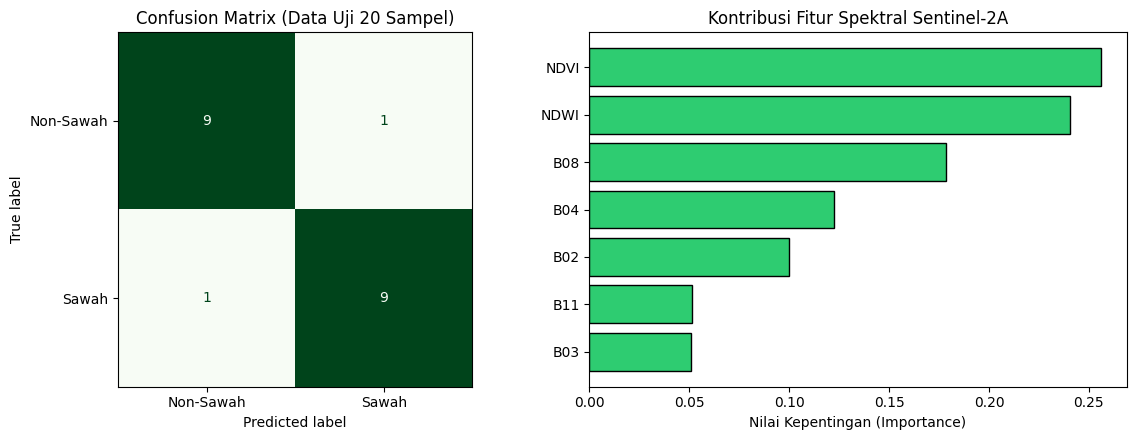

In [3]:
# ==============================================================================
# A. VISUALISASI CONFUSION MATRIX & FEATURE IMPORTANCE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Greens", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (Data Uji 20 Sampel)")

# 2. Plot Tingkat Kepentingan Fitur (Band & Indeks Spektral)
importances = model_rf.feature_importances_
indices = np.argsort(importances)
axes[1].barh(
    range(len(indices)),
    importances[indices],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([fitur_kolom[i] for i in indices])
axes[1].set_xlabel("Nilai Kepentingan (Importance)")
axes[1].set_title("Kontribusi Fitur Spektral Sentinel-2A")

plt.tight_layout()
plt.show()